In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [54]:
# 데이터셋 파일 경로 지정 및 불러오기
df = pd.read_csv('./dataset/Bank_Marketing/Bank_Marketing_Dataset.csv')

# 불필요한 인덱스 열 제거
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

print(f'데이터셋 구조: {df.shape}')
print('--- 데이터 기초 요약 정보 ---')
print(df.info())
print('\n--- 처음 5행 데이터 미리보기 ---')

데이터셋 구조: (41188, 21)
--- 데이터 기초 요약 정보 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  fl

In [55]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [56]:
# 3-1. duration 피처 제거 (전화 걸기 전엔 알 수 없는 정보)

X = df.drop(['y', 'duration'], axis=1)
y = df['y'].map({'yes': 1, 'no': 0})


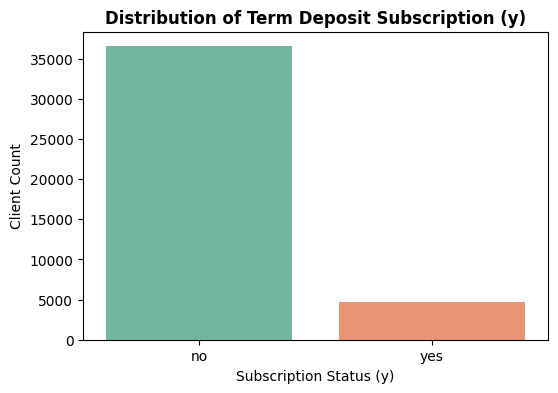

클래스 "no": 36548개 (88.73%)
클래스 "yes": 4640개 (11.27%)


In [57]:
# 3-2. 타겟 변수 y의 분포 분석 (클래스 불균형 확인)
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, palette='Set2')
plt.title('Distribution of Term Deposit Subscription (y)', fontsize=12, fontweight='bold')
plt.xlabel('Subscription Status (y)')
plt.ylabel('Client Count')
plt.show()

counts = df['y'].value_counts()
ratios = df['y'].value_counts(normalize=True) * 100
for idx, val in counts.items():
    print(f'클래스 "{idx}": {val}개 ({ratios[idx]:.2f}%)')

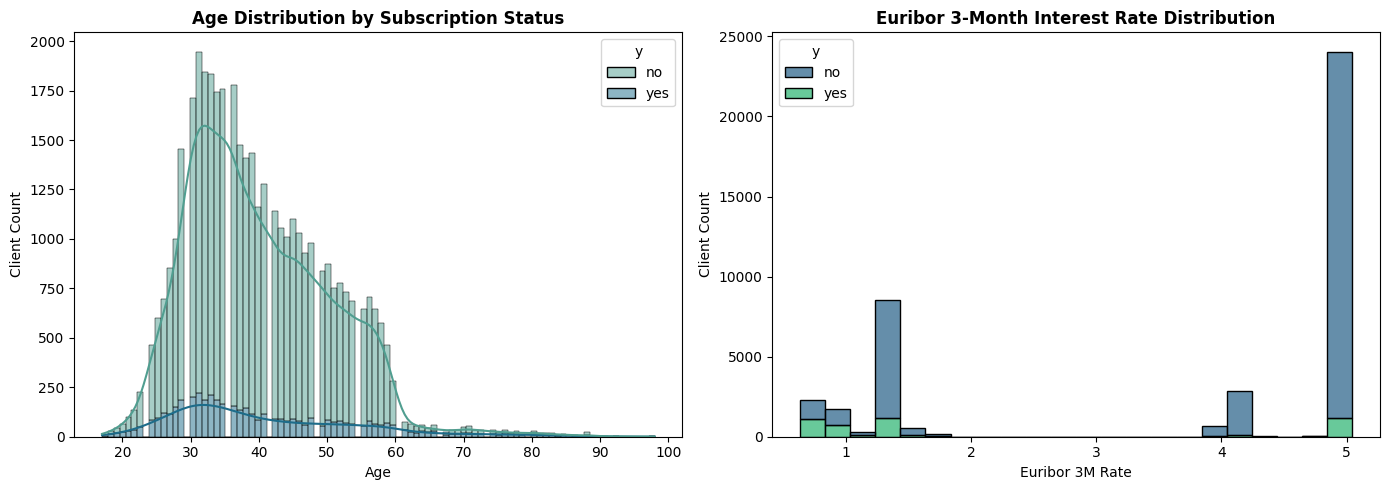

In [58]:
# 3-3. 수치형 변수(나이, 3개월 금리) 분포 분석
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 연령별 분포
sns.histplot(data=df, x='age', hue='y', multiple='stack', kde=True, ax=axes[0], palette='crest')
axes[0].set_title('Age Distribution by Subscription Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Client Count')

# 거시 금리 지표(euribor3m) 분포 - 실제 목돈 유치에 미치는 외부 요인 분석
sns.histplot(data=df, x='euribor3m', hue='y', multiple='stack', ax=axes[1], palette='viridis')
axes[1].set_title('Euribor 3-Month Interest Rate Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Euribor 3M Rate')
axes[1].set_ylabel('Client Count')

plt.tight_layout()
plt.show()

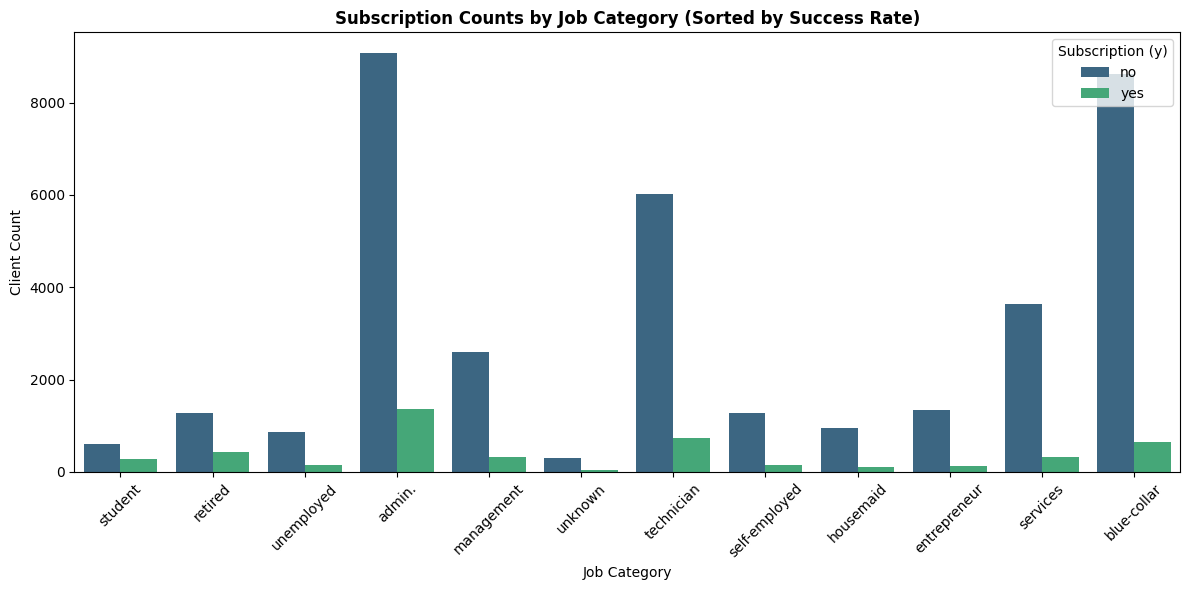

--- 직업군별 가입 성공률 ---
- student        : 가입률 31.43% (총 875명 중 275명 가입)
- retired        : 가입률 25.23% (총 1720명 중 434명 가입)
- unemployed     : 가입률 14.20% (총 1014명 중 144명 가입)
- admin.         : 가입률 12.97% (총 10422명 중 1352명 가입)
- management     : 가입률 11.22% (총 2924명 중 328명 가입)
- unknown        : 가입률 11.21% (총 330명 중 37명 가입)
- technician     : 가입률 10.83% (총 6743명 중 730명 가입)
- self-employed  : 가입률 10.49% (총 1421명 중 149명 가입)
- housemaid      : 가입률 10.00% (총 1060명 중 106명 가입)
- entrepreneur   : 가입률 8.52% (총 1456명 중 124명 가입)
- services       : 가입률 8.14% (총 3969명 중 323명 가입)
- blue-collar    : 가입률 6.89% (총 9254명 중 638명 가입)


In [59]:
# 3-3. 직업군(job)에 따른 가입률 분석 (영문 차트)
plt.figure(figsize=(12, 6))
# 가입률 기준 내림차순 정렬
job_order = df.groupby('job')['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False).index
sns.countplot(data=df, x='job', hue='y', order=job_order, palette='viridis')
plt.title('Subscription Counts by Job Category (Sorted by Success Rate)', fontsize=12, fontweight='bold')
plt.xlabel('Job Category')
plt.ylabel('Client Count')
plt.xticks(rotation=45)
plt.legend(title='Subscription (y)', loc='upper right')
plt.tight_layout()
plt.show()

print('--- 직업군별 가입 성공률 ---')
for job in job_order:
    subset = df[df['job'] == job]
    rate = (subset['y'] == 'yes').mean() * 100
    print(f'- {job:<15}: 가입률 {rate:.2f}% (총 {len(subset)}명 중 {(subset["y"] == "yes").sum()}명 가입)')


In [60]:
# 4-1. 타겟 변수 정수형 변환 및 결측치('unknown') 비율 확인
df_prep = df.copy()

# 타겟 변수 인코딩: 'yes' -> 1, 'no' -> 0
df_prep['target'] = df_prep['y'].map({'yes': 1, 'no': 0})

print('--- 범주형 특징 변수 내 "unknown"(결측치) 비율 조사 ---')
object_cols = df_prep.select_dtypes(include=['object']).columns.drop('y')
for col in object_cols:
    unknown_cnt = (df_prep[col] == 'unknown').sum()
    pct = (unknown_cnt / len(df_prep)) * 100
    if unknown_cnt > 0:
        print(f'- {col:<15} 열의 unknown 개수: {unknown_cnt:>5}개 ({pct:.2f}%)')

# 독립변수 X와 타겟 y 분리
X = df_prep.drop(['y', 'target'], axis=1)
y = df_prep['target']

--- 범주형 특징 변수 내 "unknown"(결측치) 비율 조사 ---
- job             열의 unknown 개수:   330개 (0.80%)
- marital         열의 unknown 개수:    80개 (0.19%)
- education       열의 unknown 개수:  1731개 (4.20%)
- default         열의 unknown 개수:  8597개 (20.87%)
- housing         열의 unknown 개수:   990개 (2.40%)
- loan            열의 unknown 개수:   990개 (2.40%)


In [61]:
# 4-2. One-Hot Encoding 및 데이터 분할 (Stratified Split)
from sklearn.model_selection import train_test_split

# 모든 범주형 변수를 원핫 인코딩 처리
X_encoded = pd.get_dummies(X, drop_first=True)

# Stratified Split을 사용하여 훈련/테스트셋의 클래스 비율 보존
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f'원핫 인코딩 후 피처 차원: {X_train.shape[1]}개')
print(f'훈련 데이터 크기: {X_train.shape[0]}개 | 테스트 데이터 크기: {X_test.shape[0]}개')
print(f'훈련 데이터 내 가입 비율:\n{y_train.value_counts(normalize=True) * 100}')
print(f'테스트 데이터 내 가입 비율:\n{y_test.value_counts(normalize=True) * 100}')

원핫 인코딩 후 피처 차원: 53개
훈련 데이터 크기: 32950개 | 테스트 데이터 크기: 8238개
훈련 데이터 내 가입 비율:
target
0    88.734446
1    11.265554
Name: proportion, dtype: float64
테스트 데이터 내 가입 비율:
target
0    88.73513
1    11.26487
Name: proportion, dtype: float64


In [62]:
# 4-3. 수치형 스케일링 적용
from sklearn.preprocessing import RobustScaler

numeric_cols = ['age', 'duration', 'campaign', 'pdays', 'previous', 
                'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# RobustScaler 인스턴스 생성 및 피팅
scaler = RobustScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f'스케일링 적용 후 학습 피처 구조: {X_train_scaled.shape}')
print(f'스케일링 적용 후 학습 타겟 분포:\n{y_train.value_counts()}')

스케일링 적용 후 학습 피처 구조: (32950, 53)
스케일링 적용 후 학습 타겟 분포:
target
0    29238
1     3712
Name: count, dtype: int64


In [63]:
# 5-1. 머신러닝 분류 모델 인스턴스 생성 및 훈련
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced', verbose=-1)
}

# 스케일링된 원본 훈련 데이터셋으로 모델 피팅
for name, model in models.items():
    print(f'>>> [{name}] 모델 학습 진행 중...')
    model.fit(X_train_scaled, y_train)
    print(f'    [{name}] 학습 완료.')

>>> [Logistic Regression] 모델 학습 진행 중...
    [Logistic Regression] 학습 완료.
>>> [Decision Tree] 모델 학습 진행 중...
    [Decision Tree] 학습 완료.
>>> [Random Forest] 모델 학습 진행 중...
    [Random Forest] 학습 완료.
>>> [LightGBM] 모델 학습 진행 중...
    [LightGBM] 학습 완료.


In [64]:
# 6-1. 종합 평가지표 테이블 생성
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

eval_metrics = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    eval_metrics.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })

df_metrics = pd.DataFrame(eval_metrics)
df_metrics

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.865623,0.452062,0.909483,0.603936,0.943988
1,Decision Tree,0.852149,0.427355,0.919181,0.583447,0.939110
2,Random Forest,0.915756,0.690554,0.456897,0.549935,0.948678
3,LightGBM,0.872785,0.467532,0.931034,0.622478,0.953598


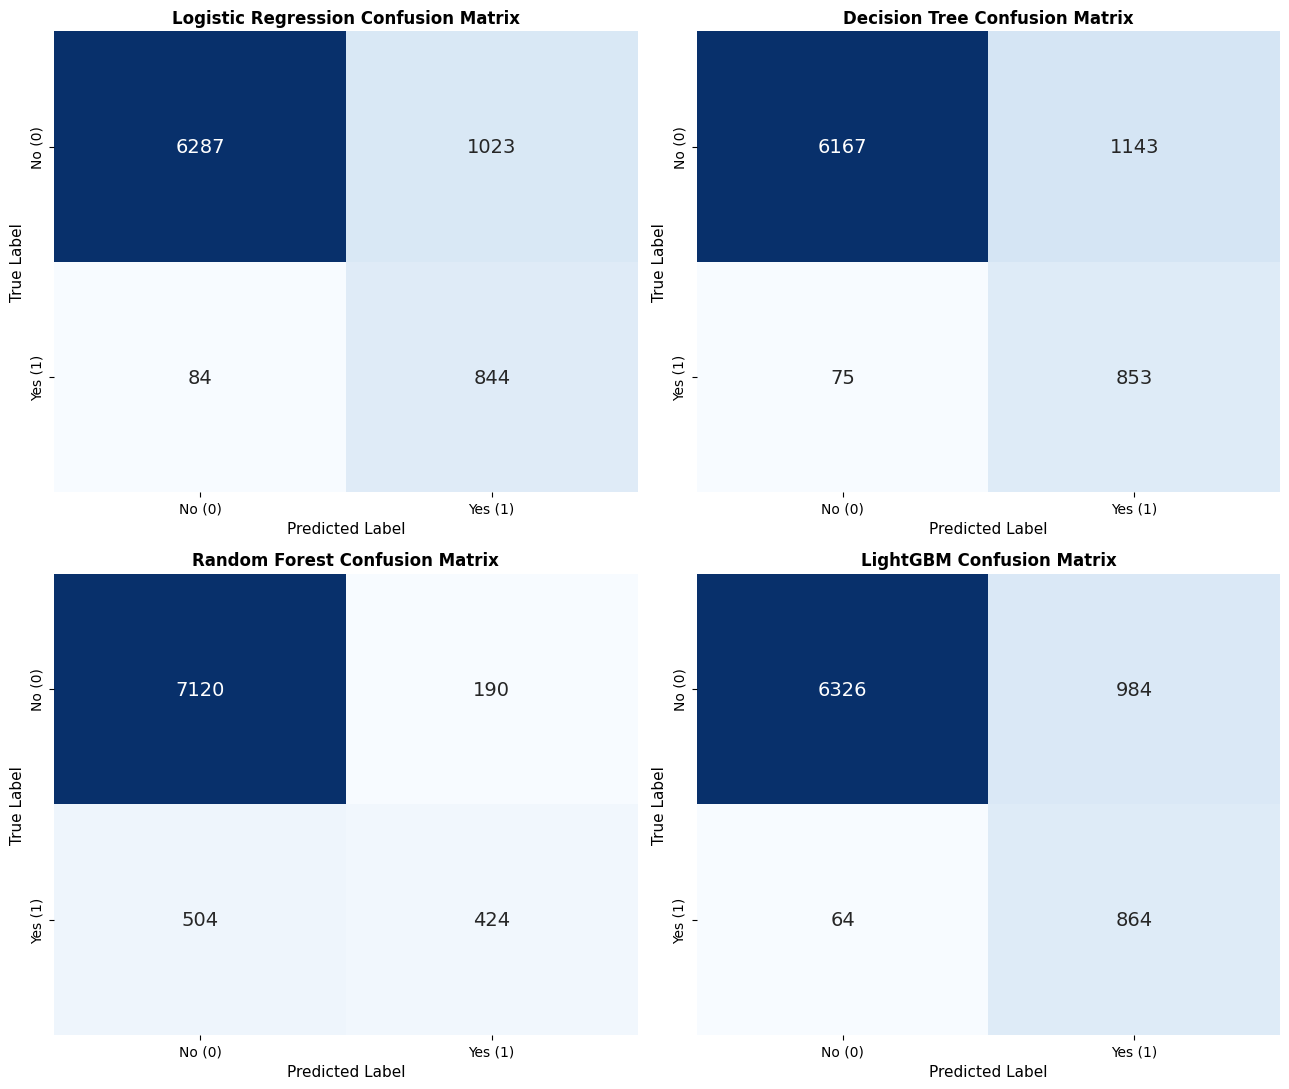

In [65]:
# 6-2. Confusion Matrix 시각화
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False, annot_kws={'size': 14})
    axes[idx].set_title(f'{name} Confusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=11)
    axes[idx].set_ylabel('True Label', fontsize=11)
    axes[idx].set_xticklabels(['No (0)', 'Yes (1)'])
    axes[idx].set_yticklabels(['No (0)', 'Yes (1)'])

plt.tight_layout()
plt.show()

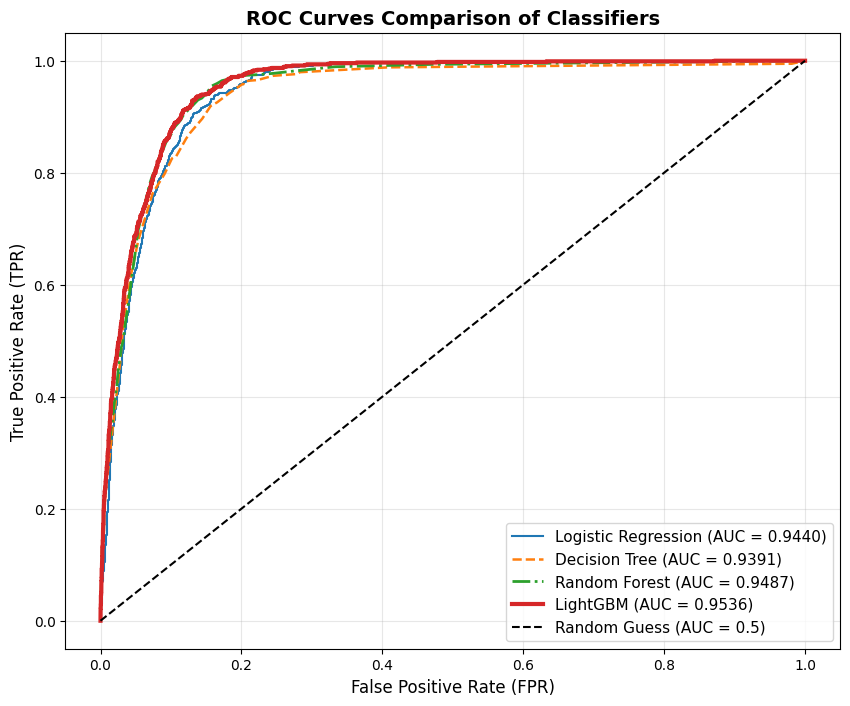

In [66]:
# 6-3. ROC 곡선 비교 시각화
from sklearn.metrics import roc_curve

model_styles = {
    'Logistic Regression': {'color': '#1f77b4', 'linestyle': '-', 'linewidth': 1.5},
    'Decision Tree': {'color': '#ff7f0e', 'linestyle': '--', 'linewidth': 1.8},
    'Random Forest': {'color': '#2ca02c', 'linestyle': '-.', 'linewidth': 2.0},
    'LightGBM': {'color': '#d62728', 'linestyle': '-', 'linewidth': 3.0}  # 최적 모델 강조
}

plt.figure(figsize=(10, 8))
for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    style = model_styles.get(name, {'color': 'gray', 'linestyle': '-', 'linewidth': 1.5})
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=style['color'], linestyle=style['linestyle'], linewidth=style['linewidth'])

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)', linewidth=1.5)
plt.title('ROC Curves Comparison of Classifiers', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

In [67]:
# 하이퍼파라미터 튜닝

from sklearn.model_selection import RandomizedSearchCV

# 탐색용 파라미터 격자 정의
param_dist = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6],
    'num_leaves': [15, 31]
}

lgb_base = LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)

random_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_dist,
    n_iter=4,
    scoring='f1',
    cv=3,
    n_jobs=1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_scaled, y_train)
print(f'최적 하이퍼파라미터 조합: {random_search.best_params_}')
print(f'교차검증 최적 평균 F1-Score: {random_search.best_score_:.4f}')

Fitting 3 folds for each of 4 candidates, totalling 12 fits
최적 하이퍼파라미터 조합: {'num_leaves': 15, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1}
교차검증 최적 평균 F1-Score: 0.6010


In [68]:
# 7-2. 하이퍼파라미터 튜닝 전후 모델 성능 비교
from sklearn.metrics import classification_report

# 튜닝 전 LightGBM 모델 성능 평가
base_model = models['LightGBM']
y_pred_base = base_model.predict(X_test_scaled)
y_prob_base = base_model.predict_proba(X_test_scaled)[:, 1]

# 튜닝 후 LightGBM 모델 성능 평가
best_model = random_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]

# 두 모델의 핵심 평가지표 계산 및 대조 테이블 매핑
metrics_compare = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Base LightGBM (Tuning 전)': [
        accuracy_score(y_test, y_pred_base),
        precision_score(y_test, y_pred_base),
        recall_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_base),
        roc_auc_score(y_test, y_prob_base)
    ],
    'Tuned LightGBM (Tuning 후)': [
        accuracy_score(y_test, y_pred_best),
        precision_score(y_test, y_pred_best),
        recall_score(y_test, y_pred_best),
        f1_score(y_test, y_pred_best),
        roc_auc_score(y_test, y_prob_best)
    ]
}
df_compare = pd.DataFrame(metrics_compare)

print('================ [성능 대조 비교] Tuning 전 vs Tuning 후 ================')
print(df_compare.to_string(index=False, formatters={
    'Base LightGBM (Tuning 전)': '{:.4f}'.format,
    'Tuned LightGBM (Tuning 후)': '{:.4f}'.format
}))
print('========================================================================')

print('\n--- [Tuning 전 Base LightGBM 최종 분류 보고서 (classification_report)] ---')
print(classification_report(y_test, y_pred_base, target_names=['No (0)', 'Yes (1)']))

print('\n--- [Tuning 후 Tuned LightGBM 최종 분류 보고서 (classification_report)] ---')
print(classification_report(y_test, y_pred_best, target_names=['No (0)', 'Yes (1)']))

================ [성능 대조 비교] Tuning 전 vs Tuning 후 ================
   Metric Base LightGBM (Tuning 전) Tuned LightGBM (Tuning 후)
 Accuracy                   0.8728                    0.8619
Precision                   0.4675                    0.4465
   Recall                   0.9310                    0.9450
 F1-Score                   0.6225                    0.6065
  ROC-AUC                   0.9536                    0.9543

--- [Tuning 전 Base LightGBM 최종 분류 보고서 (classification_report)] ---
              precision    recall  f1-score   support

      No (0)       0.99      0.87      0.92      7310
     Yes (1)       0.47      0.93      0.62       928

    accuracy                           0.87      8238
   macro avg       0.73      0.90      0.77      8238
weighted avg       0.93      0.87      0.89      8238


--- [Tuning 후 Tuned LightGBM 최종 분류 보고서 (classification_report)] ---
              precision    recall  f1-score   support

      No (0)       0.99      0.85      0.92      